In [54]:
import os
import pickle
import numpy as np
from utils.load_preprocess import load_preprocess
from utils.train_evaluate import to_labels, bayesian_optimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score, f1_score, precision_recall_curve
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from xgboost import XGBClassifier

from bayes_opt import BayesianOptimization

import shap

import warnings
warnings.filterwarnings("ignore")

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100 # This is now deprecated

# Dataset filename options: 
# 'aak81Dataset_cpmdat.csv'  - 81 out of top 100 genes from feature selection using stability
# 'dge_05.csv' - differential gene expression, genes with p < 0.05
# 'dge_all.csv' - differential gene expression, all genes
# 'overlap_81_dge.csv' - overlap of dge with 81 genes from feature selection
dataset_filename = 'aak81Dataset_cpmdat.csv'

In [55]:
X = load_preprocess(dataset_filename, as_df=True)
y = X['class'].to_numpy()
X.drop('class', 1, inplace=True)
# neg_pos_ratio = np.count_nonzero(y == 0)/np.count_nonzero(y==1)
# neg_pos_ratio

In [3]:
# Split into train, validation, and test
X_train_val, X_test, y_train_val, y_test = train_test_split(X,
                                                            y,
                                                            stratify=y,
                                                            test_size=0.2,
                                                            random_state=rng.integers(500000))
X_train, X_val, y_train, y_val = train_test_split(X_train_val,
                                                  y_train_val,
                                                  stratify=y_train_val,
                                                  test_size=0.2,
                                                  random_state=rng.integers(500000))

# Parameter bounds
param_bounds = {'eta': (0.01, 1.0),
                'n_estimators': (100, 1000),
                'gamma':(0.01, 5),
                'max_depth': (3, 11),
                'min_child_weight': (1, 11),
                'subsample': (0.5, 1),
                'reg_lambda': (0.1, 1000),
                'reg_alpha': (0.001, 1000),
                'max_delta_step':(0, 5),
                'scale_pos_weight':(1.2, 5),
                'colsample_by': (0.5, 1)}

# Function for training xgboost given hyperparameters
def xgboost_hyperparam(eta,
                       n_estimators,
                       gamma,
                       max_depth,
                       min_child_weight,
                       subsample,
                       reg_lambda,
                       reg_alpha,
                       max_delta_step,
                       scale_pos_weight,
                       colsample_by):

    max_depth = int(max_depth)
    n_estimators = int(n_estimators)
    min_child_weight = int(min_child_weight)

    model = XGBClassifier(eta=eta,
                          n_estimators=n_estimators,
                          gamma=gamma,
                          max_depth=max_depth,
                          min_child_weight=min_child_weight,
                          subsample=subsample,
                          reg_lambda=reg_lambda,
                          reg_alpha=reg_alpha,
                          max_delta_step=max_delta_step,
                          scale_pos_weight=scale_pos_weight,
                          colsample_by=colsample_by,
                          verbosity=0)

    # Fit on training data
    model.fit(X_train, y_train)

    # Get predictions on validation set
    y_pred = model.predict_proba(X_val)

    # Calculate AUROC
    auroc = roc_auc_score(y_val, y_pred[:,1])
    return auroc

# Initialize optimizer
optimizer = BayesianOptimization(f=xgboost_hyperparam,
                                 pbounds=param_bounds,
                                 random_state=1,
                                 verbose=0)

In [5]:
# Set parameters for Bayesian optimization
BAYESIAN_OPTIMIZATION_MAXIMIZE_PARAMS = dict(init_points=20,  
                                             n_iter=100,  
                                             acq='poi',
                                             xi=0.0)

# Run optimizer
optimizer.maximize(**BAYESIAN_OPTIMIZATION_MAXIMIZE_PARAMS)

# Get best hyperparameter combination from optimizer results
best_auroc = 0.
best_params = None
for details in optimizer.res:
    auroc = details['target']
    if auroc > best_auroc:
        best_auroc = auroc
        best_params = details

In [11]:
# Create model with best hyperparams
model = XGBClassifier(**best_params)

# Fit on training data
model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=16,
              num_parallel_tre...
                      'min_child_weight': 9.660881243693709,
                      'n_estimators': 412.9931752584082,
                      'reg_alpha': 7.6183676718762605,
                      'reg_lambda': 580.5490553814539,
                      'scale_pos_weight': 2.526151676290283,
                      'subsample': 0.933013709008849},
              predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, subsample=1, target=0.8735294117647059,
              tree_method='exact', validate_paramet

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [14]:
np.shape(shap_values)

(166, 81)

In [17]:
new_shap_values = shap_values

In [21]:
all_shap_values = np.vstack((shap_values, new_shap_values))

In [22]:
np.shape(all_shap_values)

(332, 81)

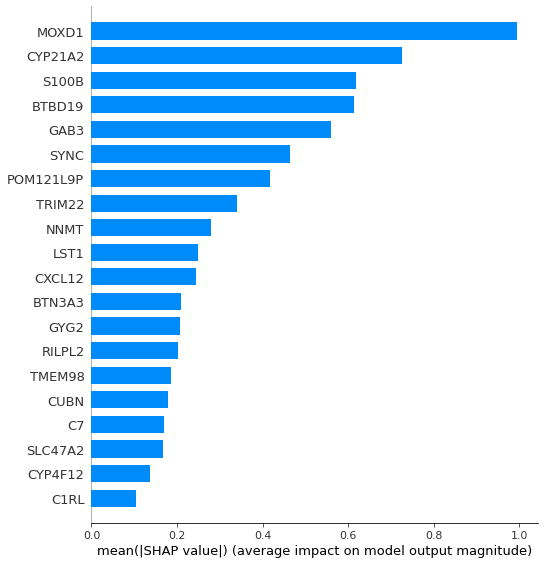

In [29]:
shap.summary_plot(all_shap_values, feature_names = X.columns, plot_type="bar")

In [38]:
shap_df = pd.DataFrame(columns=X.columns)

In [39]:
shap_df = shap_df.append(pd.DataFrame(np.abs(shap_values), columns=shap_df.columns), ignore_index=True)

In [40]:
shap_df = shap_df.append(pd.DataFrame(np.abs(new_shap_values), columns=shap_df.columns), ignore_index=True)

In [41]:
shap_df

,S100B,SYNC,PSMB8-AS1,C1S,BTN3A3,HCP5,HLA-DMB,LCTL,C3,PTGS1,...,CYTH4,C2,MAOB,CCND1,POM121L9P,DLGAP1-AS2,GALNT15,PLEKHS1,HLA-DOA,ARSD
0,0.392744,0.959392,0.012968,0.048104,0.109808,0.0,0.0,0.018291,0.031625,0.0,...,0.0,0.0,0.105578,0.017565,0.416203,0.023524,0.034806,0.034830,0.021774,0.042213
1,0.722873,0.014587,0.031225,0.219508,0.172483,0.0,0.0,0.126135,0.117927,0.0,...,0.0,0.0,0.105578,0.071788,0.346874,0.040449,0.034806,0.034830,0.008094,0.023818
2,0.560975,0.835617,0.031225,0.048104,0.162237,0.0,0.0,0.018291,0.117927,0.0,...,0.0,0.0,0.066056,0.065832,0.369745,0.081858,0.045998,0.041699,0.008094,0.087718
3,0.598960,0.082329,0.031225,0.048104,0.225025,0.0,0.0,0.019915,0.051913,0.0,...,0.0,0.0,0.105578,0.045287,0.565378,0.081858,0.045998,0.041699,0.012284,0.023818
4,0.372565,0.988844,0.012482,0.048104,0.140739,0.0,0.0,0.018291,0.020750,0.0,...,0.0,0.0,0.105578,0.022566,0.305447,0.023524,0.034806,0.041699,0.015599,0.087718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,0.784747,0.111922,0.010856,0.048104,0.137218,0.0,0.0,0.077436,0.032677,0.0,...,0.0,0.0,0.066056,0.018881,0.598214,0.015517,0.034806,0.041699,0.012284,0.023818
328,0.714052,0.434997,0.043904,0.076651,0.336247,0.0,0.0,0.060681,0.020082,0.0,...,0.0,0.0,0.105578,0.018881,0.331321,0.054179,0.034806,0.034830,0.008175,0.023818
329,0.714052,0.404241,0.043904,0.076651,0.336247,0.0,0.0,0.060681,0.020082,0.0,...,0.0,0.0,0.105578,0.132365,0.331321,0.054179,0.034806,0.034830,0.008175,0.023818
330,0.693255,0.760630,0.006673,0.076651,0.537632,0.0,0.0,0.019882,0.020082,0.0,...,0.0,0.0,0.105578,0.018881,0.319982,0.015517,0.034806,0.034830,0.006812,0.023818


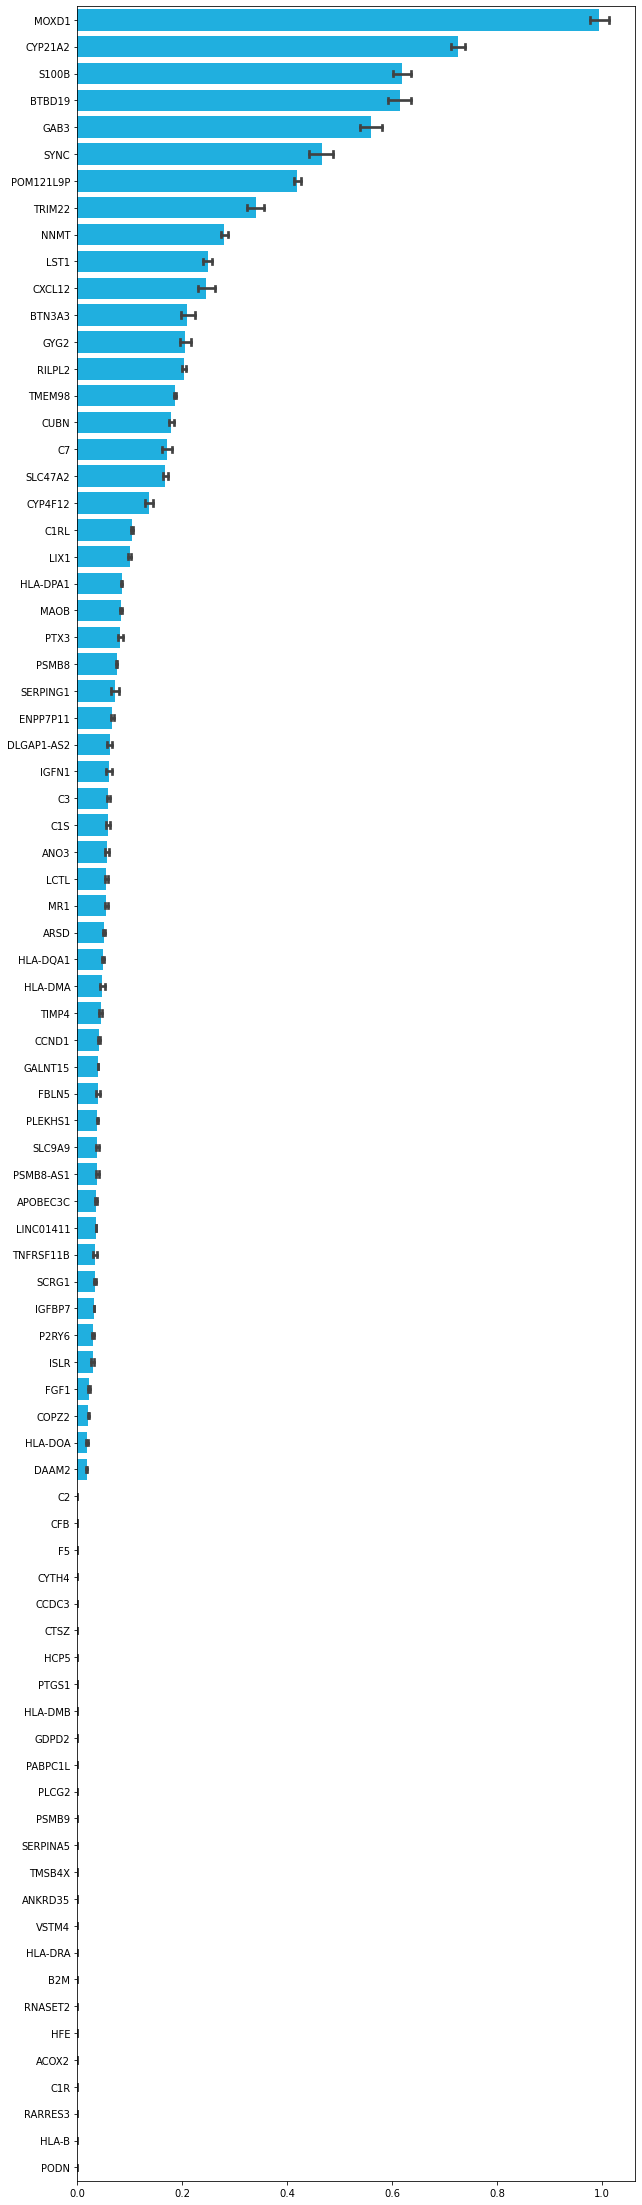

In [53]:
index_sort = shap_df.mean().sort_values(ascending=False).index
shap_df_sorted = shap_df[index_sort]

f = plt.figure(figsize=(10,40))
ax = plt.gca()
barplot = sns.barplot(data=shap_df_sorted,
                      estimator=np.mean,
                      ci=85,
                      capsize=.2,
                      color='deepskyblue',
                      orient='h',
                      ax=ax)